# Prompt Rescue Workshop

## Three weeks into a build. Accuracy at 19%. Review tomorrow.

Your client, **TechSupport Corp**, built a Claude-powered support-ticket processor — P1–P4 classification, entity extraction, and response drafting, all in one prompt. It works on clean tickets. On real-world input it falls apart: wrong priorities, hallucinated entities, broken JSON, incoherent responses.

Before tomorrow's review — before anyone suggests swapping the model — you need to know what's actually broken. That's this session.

**Your job:** Diagnose the failures, fix what's wrong, and be ready to explain your decisions clearly. A score improvement you can't explain is a demo. One with a diagnosis behind it is a methodology.

### Learning Objectives

By the end of this workshop, you will be able to:

1. **Diagnose** root causes of prompt failure — not just symptoms, but *structural* reasons
2. **Apply** prompt engineering techniques with clear rationale for each choice
3. **Evaluate** your improvements with a quantitative eval harness — no vibes-based assessment
4. **Defend** your design decisions with evidence from eval results
5. **Reflect** on what you engineered vs. what Claude did — a distinction that matters in client conversations

### Format

This is a **solo exercise**. Work at your own pace through the cells below.

**Suggested time budget:** ~15 min diagnosis → ~45 min building → ~10 min reflection

In [7]:
!pip3 install -q anthropic matplotlib --upgrade

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
# API Key Configuration
import os
ANTHROPIC_API_KEY = ""  # <-- Paste your API key here
os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

# Verify connection
import anthropic
client = anthropic.Anthropic()
test = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=50,
    messages=[{"role": "user", "content": "Say 'Connected!' and nothing else."}]
)
print(f"API Connected: {test.content[0].text}")

API Connected: Connected!


## The Scenario: TechSupport Corp

### Customer Brief

> "We're TechSupport Corp, an enterprise SaaS company. We built a prompt to handle incoming support tickets — classify priority, extract key details, and draft a response, all in one shot. It works great on simple, clearly-written tickets. But in production, maybe half the tickets are messy — multiple issues, vague descriptions, non-native English speakers. Those fail badly. JSON comes back broken, priorities are wrong, and the drafted responses sometimes contradict the classification. We need this fixed before our renewal meeting. One constraint: our ticketing pipeline has a 5-second latency budget per ticket, so solutions requiring more than 3 sequential API calls need justification."

### The Challenge

1. **Diagnose** the root causes of failure (not just symptoms — *why* does the prompt structure produce these failures?)
2. **Fix** the prompt using at least two techniques from your toolkit (see "Your Toolkit" below)
3. **Validate** your fix against the eval suite
4. **Present** a 3-minute "customer debrief" — diagnosis, fix, results, and prevention advice

### Success Criteria

| Level | Target |
|-------|--------|
| **Baseline (Pass)** | 75%+ eval pass rate, root cause identified, 2+ techniques used with justification, coherent debrief |
| **Tier 1 — Optimizer** | 90%+ pass rate, documented iteration log, monitoring prompt design |
| **Tier 2 — Architect** | Self-healing prompt chain (auto-retry on quality check failure) |

### Constraints

- **Model:** Claude Haiku (hardcoded in the eval harness — no model upgrades as a fix)
- **Architecture:** You may completely restructure the prompt — including breaking it into multiple steps or a chain — but the end-to-end function must remain the same: same inputs in, same type of outputs out
- **Process:** Track each prompt iteration. The eval harness logs your progression automatically.

In [32]:
# ============================================================
# YOUR PROMPT -- Edit this to fix the broken prompt!
# ============================================================

system_prompt_original = """
You are a support ticket processor. For each ticket, you must:
1. Classify priority (P1-P4) based on business impact
2. Extract: product name, version, error codes, affected users count
3. Draft a helpful response acknowledging the issue and providing next steps
4. Return everything as JSON: {"priority": "", "entities": {"product": "", "version": "", "error_codes": [], "affected_users": ""}, "response": "", "confidence": "high/medium/low"}

Rules:
- P1 = system down, all users affected
- P2 = major feature broken, many users affected
- P3 = minor bug, few users affected
- P4 = feature request or cosmetic issue
- If unsure about priority, use your best judgment
- Response should be professional and empathetic
- Always include all JSON fields even if empty
- Be concise but thorough
"""


system_prompt = """
You are a support ticket triage processor for TechSupport Corp.

PROCESS (in order):
1. EXTRACT entities — only verbatim spans from the ticket text.
2. CLASSIFY priority based on the HIGHEST-impact issue if multiple.
3. DRAFT a response addressing ALL issues raised.

PRIORITY RUBRIC (evaluate in order; first match wins):

- P1 — Severe. Pick ONLY if at least one is true:
    a) Core workflow is FULLY blocked (users cannot do their job at all,
       no workaround), AND revenue / payroll / compliance is at risk, OR
       all users of an org cannot work.
    b) Security / privacy incident (data exposure, PII leak, auth bypass)
       — regardless of how many users reported it.
  NOT P1: degraded performance, broken feature with workaround, "urgent"
  language, large user count alone, "production system" alone.

- P2 — Major. A significant feature is broken, slow, or unreliable for
  many users, but work continues (workaround exists, retry succeeds,
  other features function). Default for most real bugs in production.

- P3 — Minor. Use for ANY of:
    • Bug affecting few users (≤ ~5) with no business-critical impact
    • Cosmetic / UI bug (truncated text, layout, tooltip, styling)
    • Intermittent issue with reliable workaround
    • Vague complaint with some signal of real degradation but no
      extractable detail (set confidence to "low")
    • Emotional / dissatisfied ticket with no specific feature ask
      (set confidence to "low")

- P4 — Feature request ONLY. The user is asking for new functionality
  that doesn't exist yet. Urgent tone, threats to churn, or "BUG:" in
  the subject do NOT change this. If they're asking for something new,
  it's P4. Cosmetic bugs are P3, not P4.

CONFIDENCE:
- "high"   — rubric criteria met with explicit evidence in ticket.
- "medium" — criteria likely met, some inference from context.
- "low"    — ticket too vague to extract entities, OR purely emotional.
             Still ASSIGN a priority (usually P3) — do NOT leave it
             blank. Only leave priority="" if the ticket is literally
             empty of any problem signal.

ANTI-HALLUCINATION (strict):
- Entity values must be a VERBATIM substring of the ticket, or "".
  No paraphrasing, no normalization, no coining proper nouns.
  Examples of what NOT to do:
    • Ticket says "CRM tool" → product must be "CRM tool" or "", NEVER
      "CRM platform" or "CRM system".
    • Ticket says "data sync issue" → product is "", NEVER "DataSync".
    • Ticket says "API integration" → product = "API integration" (ok).
- affected_users: only a number that appears in the ticket. Words like
  "several", "a bunch", "many" → "" (never invent a number).
- error_codes: only strings appearing verbatim. Include HTTP status
  codes (e.g., "500", "429") if the ticket cites them as errors.
- version: only if a version number is literally stated.

RESPONSE RULES:
- Acknowledge every issue, not just the highest-priority one.
- Never promise a fix, timeline, or root cause not provided.
- For P4: frame as a feature request being logged. Do NOT call it a
  bug or promise a fix, even if the user used the word "bug".
- For low confidence: ask for the specific missing info (which product,
  error message, when it started, how many users).
- Plain text, under 120 words. Paraphrase instead of quoting the user
  (embedded quotes can break JSON).

OUTPUT — return ONLY this JSON, nothing before or after:
{
  "priority": "P1" | "P2" | "P3" | "P4",
  "entities": {
    "product": "",
    "version": "",
    "error_codes": [],
    "affected_users": ""
  },
  "response": "",
  "confidence": "high" | "medium" | "low"
}
All keys must be present. Use "" / [] for unknowns.

"""

print("Broken prompt loaded. Run the eval suite (Cell 7) to see your baseline score.")
print(f"Prompt length: {len(system_prompt)} characters")

Broken prompt loaded. Run the eval suite (Cell 7) to see your baseline score.
Prompt length: 3700 characters


## Failing Examples — Diagnosis Material

These are 5 real inputs where the broken prompt fails. Study the patterns before you start fixing.

---

### Example 1: Multi-issue ticket

**Input:**
```
Subject: URGENT - billing broken AND can't export data

Our billing dashboard has been showing wrong numbers since Tuesday and also the CSV export
feature throws a 500 error. We have board reporting on Friday and need both fixed. About 200
users on our team are affected by the export issue, billing is just our finance team (3 people)
but it's blocking payroll.
```

**What went wrong:** Classifies as P2 (should be P1 — payroll is blocked). Merges both issues into one entity extraction. Response only addresses the export issue, ignoring the billing/payroll problem.

---

### Example 2: Vague ticket

**Input:**
```
Subject: things arent working right

hey so a bunch of stuff seems off today? like the pages load slow and sometimes i get errors.
not sure whats happening. its been like this since the morning. thanks
```

**What went wrong:** Hallucinates product name "PageLoader" and error code "ERR_SLOW_LOAD" that don't exist anywhere in the input. Classifies as P3 when there's not enough info to classify confidently.

---

### Example 3: Non-native English

**Input:**
```
Subject: Probleme mit der Integration

Hello, we have problem with API integration since update to version 3.2. The webhook is not
fire correctly and data is missing in dashboard. Very urgent for us because is production
system for 50 customer. Error say "timeout exceeded" sometimes.
```

**What went wrong:** JSON output is malformed — the response field contains a quote that breaks the JSON structure. Priority is correct (P2) but entities miss the version number.

---

### Example 4: Feature request disguised as bug

**Input:**
```
Subject: BUG: No dark mode support

This is a critical usability bug. Your application doesn't support dark mode which causes eye
strain for our entire team working night shifts (15 people). This should have been implemented
long ago. We need this resolved immediately or we'll consider switching providers.
```

**What went wrong:** Classifies as P2 due to urgent language, when this is clearly P4 (feature request). Response promises to "fix the bug" which sets wrong customer expectations.

---

### Example 5: Clean ticket (regression check)

**Input:**
```
Subject: Error 503 on login page

Since 2pm EST today, all users (approximately 500) in our organization are unable to log into
the platform. We receive a 503 Service Unavailable error. This is our primary CRM tool and
sales team is completely blocked. Error code: SVC-503-AUTH. Running version 4.1.2.
```

**What went wrong:** Actually handles this correctly most of the time (clean input). Include to verify fixes don't regress on easy cases.

In [33]:
#@title Eval Harness (click to load -- do not edit this cell)

# ============================================================
# EVAL HARNESS -- All evaluation logic is embedded here.
# Run this cell once to load the harness functions.
# ============================================================

import json
import re
import base64
import time
from datetime import datetime
import anthropic
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML
matplotlib.rcParams['figure.facecolor'] = 'white'

# ---------------------------------------------------------------------------
# Embedded eval cases (base64-encoded to discourage casual peeking)
# ---------------------------------------------------------------------------

_EVAL_CASES_B64 = "..."

# ---------------------------------------------------------------------------
# Global state
# ---------------------------------------------------------------------------

_iteration_log = []
_baseline_score = None
_baseline_total = None

MODEL = "claude-haiku-4-5"
MAX_TOKENS = 4096

# ---------------------------------------------------------------------------
# Case loader
# ---------------------------------------------------------------------------

def _load_cases(encoded):
    return json.loads(base64.b64decode(encoded).decode("utf-8"))

# ---------------------------------------------------------------------------
# Scoring module (ported from scoring.py)
# ---------------------------------------------------------------------------

REQUIRED_FIELDS = {"priority", "entities", "response", "confidence"}
REQUIRED_ENTITY_FIELDS = {"product", "version", "error_codes", "affected_users"}


def parse_output(raw_output):
    """Extract JSON from model output, handling nested objects."""
    try:
        parsed = json.loads(raw_output.strip())
        return parsed, None
    except json.JSONDecodeError:
        pass
    start_indices = [i for i, c in enumerate(raw_output) if c == '{']
    for start in start_indices:
        brace_count = 0
        for end in range(start, len(raw_output)):
            if raw_output[end] == '{':
                brace_count += 1
            elif raw_output[end] == '}':
                brace_count -= 1
            if brace_count == 0:
                candidate = raw_output[start:end + 1]
                try:
                    parsed = json.loads(candidate)
                    return parsed, None
                except json.JSONDecodeError:
                    break
    return None, "Output is not valid JSON"


def check_valid_json(parsed, error):
    if parsed is None:
        return False, error or "Output is not valid JSON"
    missing_top = REQUIRED_FIELDS - set(parsed.keys())
    if missing_top:
        return False, f"Missing required fields: {', '.join(sorted(missing_top))}"
    entities = parsed.get("entities")
    if not isinstance(entities, dict):
        return False, "Field 'entities' must be a JSON object"
    missing_entity = REQUIRED_ENTITY_FIELDS - set(entities.keys())
    if missing_entity:
        return False, f"Missing entity fields: {', '.join(sorted(missing_entity))}"
    return True, "Valid JSON with all required fields"


def check_priority(parsed, gold_priority):
    if parsed is None:
        return False, "Cannot check priority -- invalid JSON"
    output_priority = str(parsed.get("priority", "")).strip().upper()
    expected = gold_priority.strip().upper()
    if output_priority == expected:
        return True, f"Priority correct: {expected}"
    return False, f"Priority={output_priority}, expected={expected}"


def _normalize_value(val):
    return re.sub(r'[\s\-_\.]+', ' ', str(val).lower().strip())


_NULL_EQUIVALENT_PATTERN = re.compile(
    r'^('
    r'null|none|n/?a|unknown|unspecified|not\s+specified'
    r'|not\s+provided|not\s+mentioned|not\s+available'
    r'|unknown\s*[-\u2014\u2013]\s*not\s+\w+'
    r'|\w+\s*\(unspecified[^)]*\)'
    r')$',
    re.IGNORECASE,
)


def _is_null_equivalent(val_str):
    """Return True if a value is semantically null (model saying 'not present')."""
    return bool(_NULL_EQUIVALENT_PATTERN.match(val_str.strip()))


def _strip_annotations(val):
    """Strip parenthetical suffixes and leading approximation markers."""
    val = re.sub(r'\s*\(.*?\)\s*$', '', val)
    val = re.sub(r'^[~\u2248]\s*', '', val)
    return val.strip()


def _value_in_input(value, input_text):
    """Check if an entity value is derivable from the input text."""
    if value is None or value == "" or value == []:
        return True
    input_lower = input_text.lower()
    input_normalized = _normalize_value(input_text)
    if isinstance(value, list):
        return all(_value_in_input(v, input_text) for v in value)
    val_str = str(value).strip()
    if not val_str or _is_null_equivalent(val_str):
        return True
    val_lower = val_str.lower()
    val_normalized = _normalize_value(val_str)
    if val_lower in input_lower:
        return True
    if val_normalized in input_normalized:
        return True
    if re.match(r'^\d+$', val_str):
        if re.search(r'\b' + re.escape(val_str) + r'\b', input_text):
            return True
    if re.match(r'^\d+\.\d+(\.\d+)?$', val_str):
        if val_str in input_text:
            return True
    # Fallback: strip annotations and retry
    stripped = _strip_annotations(val_str)
    if stripped and stripped != val_str:
        if _value_in_input(stripped, input_text):
            return True
    # Fallback: numeric value with approximation in input
    num_match = re.match(r'^[~\u2248]?\s*(\d+(?:\.\d+)?)\s*$', val_str)
    if num_match:
        number = num_match.group(1)
        approx_pattern = (
            r'(?:approximately|about|around|roughly|~|\u2248)\s*'
            + re.escape(number)
        )
        if re.search(approx_pattern, input_text, re.IGNORECASE):
            return True
        if re.search(r'\b' + re.escape(number) + r'\b', input_text):
            return True
    # Fallback: comma-separated multi-values
    if ',' in val_str:
        parts = [p.strip() for p in val_str.split(',') if p.strip()]
        if len(parts) > 1 and all(
            _value_in_input(part, input_text) for part in parts
        ):
            return True
    return False


def check_entities(parsed, input_text, gold_entities):
    if parsed is None:
        return False, "Cannot check entities -- invalid JSON"
    entities = parsed.get("entities", {})
    if not isinstance(entities, dict):
        return False, "Entities field is not a JSON object"
    hallucinated = []
    for field in REQUIRED_ENTITY_FIELDS:
        value = entities.get(field)
        if value is None or value == "" or value == []:
            continue
        if not _value_in_input(value, input_text):
            hallucinated.append(f"{field}={json.dumps(value)}")
    if hallucinated:
        return False, f"Possible hallucinated entities: {'; '.join(hallucinated)}"
    return True, "All entities derivable from input"


def score_case(parsed, parse_error, input_text, gold_priority, gold_entities,
               response_coherent=None, audited=False):
    json_ok, json_reason = check_valid_json(parsed, parse_error)
    priority_ok, priority_reason = (False, "Skipped -- invalid JSON") if not json_ok else check_priority(parsed, gold_priority)
    entities_ok, entities_reason = (False, "Skipped -- invalid JSON") if not json_ok else check_entities(parsed, input_text, gold_entities)
    if not audited:
        response_ok = True
        response_reason = "Auto-pass (non-audited case)"
    elif not json_ok:
        response_ok = False
        response_reason = "Skipped -- invalid JSON"
    elif response_coherent is None:
        response_ok = True
        response_reason = "Pending judge evaluation"
    else:
        response_ok = response_coherent
        response_reason = "Judge: PASS" if response_coherent else "Judge: FAIL"
    all_pass = json_ok and priority_ok and entities_ok and response_ok
    return {
        "pass": all_pass,
        "criteria": {
            "json_valid": {"pass": json_ok, "reason": json_reason},
            "priority_correct": {"pass": priority_ok, "reason": priority_reason},
            "entities_accurate": {"pass": entities_ok, "reason": entities_reason},
            "response_coherent": {"pass": response_ok, "reason": response_reason},
        },
    }

# ---------------------------------------------------------------------------
# Judge prompt module (ported from judge_prompts.py)
# ---------------------------------------------------------------------------

JUDGE_SYSTEM_PROMPT = """You are an eval judge for a support ticket processing system. Your job is to assess whether a drafted response appropriately addresses the support ticket given the priority classification.

Rules:
- The response must not contradict the priority classification
- The response must address the actual content of the ticket
- For feature requests classified as P4: the response must NOT promise to "fix" it or treat it as a bug
- For vague tickets: the response should ask for more information
- For multi-issue tickets: the response should acknowledge all issues mentioned
- Tone should be professional regardless of the ticket's tone

Reply with exactly one line: PASS or FAIL followed by a one-sentence reason.
Example: PASS - Response appropriately acknowledges the feature request and sets expectations.
Example: FAIL - Response promises to fix a feature request as if it were a bug."""


def judge_response(client, input_text, priority, response_text):
    user_message = f"""Evaluate this support ticket response:

SUPPORT TICKET:
{input_text}

ASSIGNED PRIORITY: {priority}

DRAFTED RESPONSE:
{response_text}

Does the response appropriately address the ticket without contradicting the classification? Reply PASS or FAIL with a one-sentence reason."""
    try:
        result = _call_api_with_retry(
            client, model=MODEL, max_tokens=150, system=JUDGE_SYSTEM_PROMPT,
            messages=[{"role": "user", "content": user_message}],
        )
        judge_output = result.content[0].text.strip()
        if judge_output.upper().startswith("PASS"):
            return True, judge_output
        elif judge_output.upper().startswith("FAIL"):
            return False, judge_output
        else:
            return True, f"Ambiguous judge output (defaulting to PASS): {judge_output}"
    except Exception as e:
        return True, f"Judge call failed (defaulting to PASS): {e}"

# ---------------------------------------------------------------------------
# Core eval runner
# ---------------------------------------------------------------------------

def _call_api_with_retry(client, **kwargs):
    """Wrap API calls with exponential backoff for rate limits and overloaded errors."""
    delays = [1, 2, 4]
    last_err = None
    for attempt in range(len(delays) + 1):
        try:
            return client.messages.create(**kwargs)
        except anthropic.RateLimitError as e:
            last_err = e
        except anthropic.APIStatusError as e:
            if e.status_code == 529:
                last_err = e
            else:
                raise
        if attempt < len(delays):
            print(f" (retry {attempt+1} in {delays[attempt]}s)", end="", flush=True)
            time.sleep(delays[attempt])
    raise last_err


def run_single_prompt(client, system_prompt, user_input):
    result = _call_api_with_retry(
        client, model=MODEL, max_tokens=MAX_TOKENS, system=system_prompt,
        messages=[{"role": "user", "content": user_input}],
    )
    return result.content[0].text


def run_chain(client, prompts, user_input):
    output = ""
    step_outputs = []
    for i, system_prompt in enumerate(prompts):
        if i == 0:
            user_message = user_input
        else:
            parts = [f"ORIGINAL TICKET:\n{user_input}"]
            for j, prev_output in enumerate(step_outputs):
                parts.append(f"STEP {j+1} OUTPUT:\n{prev_output}")
            user_message = "\n\n".join(parts)
        try:
            output = run_single_prompt(client, system_prompt, user_message)
        except Exception as e:
            output = json.dumps({"error": f"Chain step {i+1} failed: {e}"})
        step_outputs.append(output)
    return output


def run_eval(client, prompts, cases_data, verbose=False):
    cases = cases_data["cases"]
    categories = cases_data["categories"]
    total = len(cases)
    results = []
    print(f"Running {total} eval cases...")
    for i, case in enumerate(cases):
        case_id = case["id"]
        print(f"  Case {case_id:>2}/{total}...", end="", flush=True)
        try:
            if len(prompts) == 1:
                raw_output = run_single_prompt(client, prompts[0], case["input"])
            else:
                raw_output = run_chain(client, prompts, case["input"])
        except Exception as e:
            raw_output = f"API ERROR: {e}"
        parsed, parse_error = parse_output(raw_output)
        response_coherent = None
        if case.get("audited_response") and parsed:
            priority = parsed.get("priority", "")
            response_text = parsed.get("response", "")
            if response_text:
                judge_pass, judge_reason = judge_response(client, case["input"], priority, response_text)
                response_coherent = judge_pass
        result = score_case(
            parsed=parsed, parse_error=parse_error, input_text=case["input"],
            gold_priority=case["gold_priority"], gold_entities=case["gold_entities"],
            response_coherent=response_coherent, audited=case.get("audited_response", False),
        )
        result["case_id"] = case_id
        result["category"] = case["category"]
        result["raw_output"] = raw_output
        results.append(result)
        status = "PASS" if result["pass"] else "FAIL"
        if result["pass"]:
            print(f" {status}")
        else:
            failed_criteria = [
                name for name, crit in result["criteria"].items()
                if not crit["pass"]
            ]
            reasons = [
                f'{name}: {result["criteria"][name]["reason"]}'
                for name in failed_criteria
            ]
            print(f" {status} [{'; '.join(reasons)}]")
    category_results = {}
    for cat_key, cat_info in categories.items():
        cat_case_ids = cat_info["case_ids"]
        cat_results = [r for r in results if r["case_id"] in cat_case_ids]
        passed = sum(1 for r in cat_results if r["pass"])
        category_results[cat_key] = {
            "label": cat_info["label"],
            "passed": passed,
            "total": len(cat_results),
        }
    total_passed = sum(1 for r in results if r["pass"])
    return {
        "results": results, "categories": category_results,
        "total_passed": total_passed, "total_cases": total,
    }

# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------

def _score_color(pct):
    if pct >= 80: return "#22c55e"
    if pct >= 60: return "#eab308"
    return "#ef4444"


def _display_results(eval_result, label="Current"):
    global _baseline_score, _baseline_total
    total_passed = eval_result["total_passed"]
    total_cases = eval_result["total_cases"]
    pct = round(100 * total_passed / total_cases) if total_cases else 0
    color = _score_color(pct)

    baseline_html = ""
    if _baseline_score is not None:
        bl_pct = round(100 * _baseline_score / _baseline_total)
        diff = total_passed - _baseline_score
        diff_str = f"+{diff}" if diff >= 0 else str(diff)
        diff_color = "#22c55e" if diff > 0 else ("#ef4444" if diff < 0 else "#6b7280")
        baseline_html = f'<div style="font-size:16px;color:#6b7280;margin-top:4px;">Baseline: {_baseline_score}/{_baseline_total} ({bl_pct}%) &rarr; Current: {total_passed}/{total_cases} ({pct}%) <span style="color:{diff_color};font-weight:bold;">[{diff_str}]</span></div>'

    html = f'''
    <div style="background:#f8fafc;border:2px solid {color};border-radius:12px;padding:24px;margin:16px 0;font-family:system-ui,-apple-system,sans-serif;">
      <div style="text-align:center;">
        <div style="font-size:14px;color:#6b7280;text-transform:uppercase;letter-spacing:1px;">{label}</div>
        <div style="font-size:64px;font-weight:bold;color:{color};">{total_passed}/{total_cases}</div>
        <div style="font-size:24px;color:{color};">({pct}%)</div>
        {baseline_html}
      </div>
    </div>
    '''
    display(HTML(html))

    cats = eval_result["categories"]
    labels = [cats[k]["label"] for k in cats]
    passed = [cats[k]["passed"] for k in cats]
    totals = [cats[k]["total"] for k in cats]
    failed = [t - p for t, p in zip(totals, passed)]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    y_pos = range(len(labels))
    ax.barh(y_pos, passed, color='#22c55e', label='Passed', height=0.6)
    ax.barh(y_pos, failed, left=passed, color='#fee2e2', label='Failed', height=0.6)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Cases', fontsize=12)
    ax.set_title('Score by Category', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    for i, (p, t) in enumerate(zip(passed, totals)):
        ax.text(t + 0.1, i, f'{p}/{t}', va='center', fontsize=11, fontweight='bold')
    ax.set_xlim(0, max(totals) + 1.5)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def _log_run(label, eval_result):
    _iteration_log.append({
        "timestamp": datetime.now().strftime("%H:%M:%S"),
        "label": label,
        "passed": eval_result["total_passed"],
        "total": eval_result["total_cases"],
        "pct": round(100 * eval_result["total_passed"] / eval_result["total_cases"]),
        "categories": {k: v.copy() for k, v in eval_result["categories"].items()},
    })

# ---------------------------------------------------------------------------
# Public API -- these are the functions teams use
# ---------------------------------------------------------------------------

def run_eval_suite(prompt_or_prompts, label="Current"):
    """Run the full eval suite and display visual results.

    Args:
        prompt_or_prompts: Either a single system prompt string,
                          or a list of prompt strings for chain mode.
        label: A label for this run (shown in results and iteration log).
    """
    global _baseline_score, _baseline_total

    client = anthropic.Anthropic()
    cases_data = _load_cases(_EVAL_CASES_B64)

    if isinstance(prompt_or_prompts, str):
        prompts = [prompt_or_prompts]
        mode = "single prompt"
    else:
        prompts = list(prompt_or_prompts)
        mode = f"{len(prompts)}-step chain"

    print(f"Mode: {mode}")
    print(f"Model: {MODEL}")
    print()

    start_time = time.time()
    eval_result = run_eval(client, prompts, cases_data)
    elapsed = time.time() - start_time

    print(f"\nCompleted in {elapsed:.1f}s")

    if _baseline_score is None:
        _baseline_score = eval_result["total_passed"]
        _baseline_total = eval_result["total_cases"]
        print(f"Baseline set: {_baseline_score}/{_baseline_total}")

    _log_run(label, eval_result)
    _display_results(eval_result, label=label)
    return eval_result


def compare_prompts(prompt_a, prompt_b, label_a="Variant A", label_b="Variant B"):
    """Run two prompt variants and display side-by-side comparison."""
    client = anthropic.Anthropic()
    cases_data = _load_cases(_EVAL_CASES_B64)

    prompts_a = [prompt_a] if isinstance(prompt_a, str) else list(prompt_a)
    prompts_b = [prompt_b] if isinstance(prompt_b, str) else list(prompt_b)

    print(f"Running {label_a}...")
    result_a = run_eval(client, prompts_a, cases_data)
    print(f"\nRunning {label_b}...")
    result_b = run_eval(client, prompts_b, cases_data)

    _log_run(label_a, result_a)
    _log_run(label_b, result_b)

    pct_a = round(100 * result_a["total_passed"] / result_a["total_cases"])
    pct_b = round(100 * result_b["total_passed"] / result_b["total_cases"])

    html = f'''
    <div style="display:flex;gap:16px;margin:16px 0;font-family:system-ui,-apple-system,sans-serif;">
      <div style="flex:1;background:#f8fafc;border:2px solid {_score_color(pct_a)};border-radius:12px;padding:20px;text-align:center;">
        <div style="font-size:13px;color:#6b7280;text-transform:uppercase;">{label_a}</div>
        <div style="font-size:48px;font-weight:bold;color:{_score_color(pct_a)};">{result_a["total_passed"]}/{result_a["total_cases"]}</div>
        <div style="font-size:20px;color:{_score_color(pct_a)};">({pct_a}%)</div>
      </div>
      <div style="flex:1;background:#f8fafc;border:2px solid {_score_color(pct_b)};border-radius:12px;padding:20px;text-align:center;">
        <div style="font-size:13px;color:#6b7280;text-transform:uppercase;">{label_b}</div>
        <div style="font-size:48px;font-weight:bold;color:{_score_color(pct_b)};">{result_b["total_passed"]}/{result_b["total_cases"]}</div>
        <div style="font-size:20px;color:{_score_color(pct_b)};">({pct_b}%)</div>
      </div>
    </div>
    '''
    display(HTML(html))

    cats_a = result_a["categories"]
    cats_b = result_b["categories"]
    cat_keys = list(cats_a.keys())
    labels = [cats_a[k]["label"] for k in cat_keys]
    scores_a = [cats_a[k]["passed"] for k in cat_keys]
    scores_b = [cats_b[k]["passed"] for k in cat_keys]
    totals = [cats_a[k]["total"] for k in cat_keys]

    fig, ax = plt.subplots(figsize=(10, 4))
    y = range(len(labels))
    bar_height = 0.35
    ax.barh([i - bar_height/2 for i in y], scores_a, bar_height, label=label_a, color='#3b82f6')
    ax.barh([i + bar_height/2 for i in y], scores_b, bar_height, label=label_b, color='#f97316')
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=12)
    ax.set_xlabel('Cases Passed', fontsize=12)
    ax.set_title('Category Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    for i, (sa, sb, t) in enumerate(zip(scores_a, scores_b, totals)):
        ax.text(max(sa, sb) + 0.15, i, f'/{t}', va='center', fontsize=10, color='#6b7280')
    ax.set_xlim(0, max(totals) + 1.5)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    rows = ""
    for k in cat_keys:
        sa = cats_a[k]["passed"]
        sb = cats_b[k]["passed"]
        t = cats_a[k]["total"]
        diff = sb - sa
        winner = label_b if diff > 0 else (label_a if diff < 0 else "Tie")
        diff_color = "#22c55e" if diff > 0 else ("#ef4444" if diff < 0 else "#6b7280")
        diff_str = f"+{diff}" if diff > 0 else str(diff)
        rows += f'<tr><td>{cats_a[k]["label"]}</td><td>{sa}/{t}</td><td>{sb}/{t}</td><td style="color:{diff_color};font-weight:bold;">{diff_str}</td><td>{winner}</td></tr>'

    table_html = f'''
    <table style="border-collapse:collapse;width:100%;margin:16px 0;font-family:system-ui,-apple-system,sans-serif;">
    <thead><tr style="background:#f1f5f9;"><th style="padding:8px;text-align:left;">Category</th><th>{label_a}</th><th>{label_b}</th><th>Delta</th><th>Winner</th></tr></thead>
    <tbody>{rows}</tbody>
    </table>
    '''
    display(HTML(table_html))
    return result_a, result_b


def show_iteration_log():
    """Display the iteration history as a table and line chart."""
    if not _iteration_log:
        print("No iterations logged yet. Run run_eval_suite() first.")
        return

    rows = ""
    for i, entry in enumerate(_iteration_log):
        color = _score_color(entry["pct"])
        rows += f'<tr><td>{i+1}</td><td>{entry["timestamp"]}</td><td>{entry["label"]}</td><td style="color:{color};font-weight:bold;">{entry["passed"]}/{entry["total"]} ({entry["pct"]}%)</td></tr>'

    table_html = f'''
    <h3 style="font-family:system-ui,-apple-system,sans-serif;">Iteration Log</h3>
    <table style="border-collapse:collapse;width:100%;margin:8px 0;font-family:system-ui,-apple-system,sans-serif;">
    <thead><tr style="background:#f1f5f9;"><th style="padding:8px;text-align:left;">#</th><th>Time</th><th>Label</th><th>Score</th></tr></thead>
    <tbody>{rows}</tbody>
    </table>
    '''
    display(HTML(table_html))

    if len(_iteration_log) > 1:
        fig, ax = plt.subplots(figsize=(10, 4))
        x = range(1, len(_iteration_log) + 1)
        pcts = [e["pct"] for e in _iteration_log]
        ax.plot(x, pcts, 'o-', color='#3b82f6', linewidth=2, markersize=8)
        ax.axhline(y=75, color='#22c55e', linestyle='--', alpha=0.7, label='Pass threshold (75%)')
        ax.axhline(y=90, color='#eab308', linestyle='--', alpha=0.7, label='Optimizer tier (90%)')
        for i, (xi, pct) in enumerate(zip(x, pcts)):
            ax.annotate(f'{pct}%', (xi, pct), textcoords="offset points",
                        xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Pass Rate (%)', fontsize=12)
        ax.set_title('Score Progression', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.set_xticks(list(x))
        ax.set_xticklabels([e["label"][:20] for e in _iteration_log], rotation=30, ha='right', fontsize=9)
        ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()


print("Eval harness loaded.")
print()
print("Available functions:")
print("  run_eval_suite(prompt_or_prompts, label='...')  -- Run full eval, display visual results")
print("  compare_prompts(prompt_a, prompt_b, ...)        -- A/B comparison of two variants")
print("  show_iteration_log()                            -- Show all runs + score progression chart")


Eval harness loaded.

Available functions:
  run_eval_suite(prompt_or_prompts, label='...')  -- Run full eval, display visual results
  compare_prompts(prompt_a, prompt_b, ...)        -- A/B comparison of two variants
  show_iteration_log()                            -- Show all runs + score progression chart


Mode: single prompt
Model: claude-haiku-4-5

Running 21 eval cases...
  Case  1/21... PASS
  Case  2/21... PASS
  Case  3/21... PASS
  Case  4/21... PASS
  Case  5/21... PASS
  Case  6/21... PASS
  Case  7/21... PASS
  Case  8/21... PASS
  Case  9/21... PASS
  Case 10/21... PASS
  Case 11/21... PASS
  Case 12/21... PASS
  Case 13/21... PASS
  Case 14/21... PASS
  Case 15/21... PASS
  Case 16/21... PASS
  Case 17/21... PASS
  Case 18/21... PASS
  Case 19/21... PASS
  Case 20/21... PASS
  Case 21/21... FAIL [priority_correct: Priority=P2, expected=P3]

Completed in 74.3s
Baseline set: 20/21


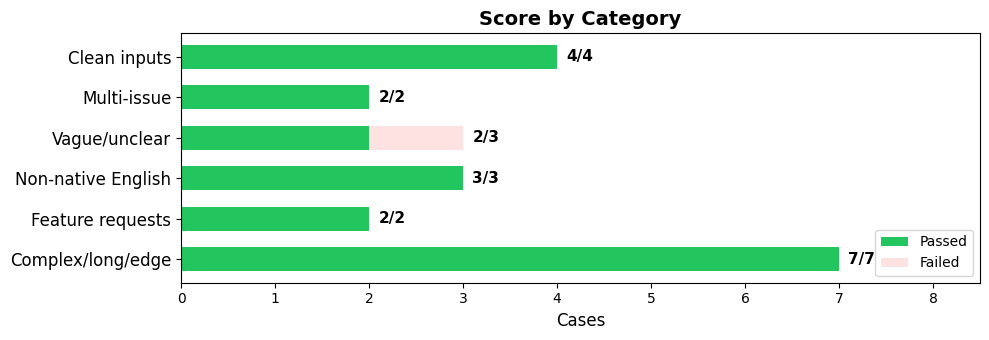

In [34]:
# ============================================================
# RUN YOUR FIRST EVAL -- Establish your baseline score
# ============================================================

results = run_eval_suite(system_prompt, label="Baseline (Broken Prompt)")

---

### Before you name the root cause: run a diagnostic with Claude

Claude is useful as a diagnostic tool here. Before you decide what's wrong, open a new Claude conversation and paste the 5 failing examples (Cell 4) with this prompt:

> "Here are 5 cases where a support ticket classifier is failing. What structural patterns do you see? What are the most likely root causes?"

Treat the output like a profiler result — a set of hypotheses to evaluate, not a verdict to accept. Do you agree with what it identified? Did it miss anything?

Then name your own diagnosis before moving on.

---

## Score Benchmarks

| Stage | Expected Score | What It Means |
|-------|---------------|---------------|
| Baseline (broken prompt) | ~4/21 (19%) | The starting point — lots of room to improve |
| Good single-prompt fix | 9–12/21 (43–57%) | You've addressed the major issues |
| Strong chain solution | 16–19/21 (76–90%) | Excellent — you've mastered the techniques |
| Reference solution | 21/21 (100%) | The gold standard |

Don't worry if your baseline is low — that's by design! The goal is to iterate and improve.

## Diagnosis Guidance

Before you start fixing, spend 10–15 minutes *understanding* what's wrong. Treat this like a real engagement — diagnose before you prescribe.

### Where to focus

Look at the **category breakdown** from your baseline eval:
- Which categories score 0? Those are your highest-leverage targets.
- Which categories already pass? Protect those — fixes for hard cases often break easy ones.

### Patterns to look for in the failing examples

1. **Task interference** — The prompt asks the model to classify, extract, *and* draft a response simultaneously. When the response-drafting task activates empathetic language, it can inflate the priority classification. When extraction finds nothing, the model invents entities to fill the fields.

2. **Hallucinated entities** — The prompt says "Always include all JSON fields even if empty." The model interprets "include" as "fill in" rather than "leave as null." Vague tickets trigger fabricated product names and error codes.

3. **Emotional tone biasing priority** — The prompt defines P1 as "system down, all users affected" but doesn't say *ignore the tone and focus on the content*. Angry or urgent language inflates priority even when the actual issue is a feature request.

4. **Feature requests misclassified** — Without explicit examples showing that urgent-sounding feature requests are still P4, the model defaults to matching urgency words to high priority levels.

### Try meta-prompting

Paste the broken prompt into a fresh Claude conversation along with 2–3 failing examples. Ask:

> "What structural issues in this prompt could cause these outputs? Be specific about which instructions are ambiguous, conflicting, or missing."

This is one of the most powerful diagnostic tools in your toolkit — use Claude to analyze its own prompt.

---

### Not sure which technique fits? Ask Claude.

Take the failure pattern you just diagnosed and ask Claude:

> "I'm fixing a prompt that fails on [describe your failure mode]. Which of these would you recommend: meta-prompting, prompt chaining, few-shot examples, or constraint sharpening? Give me your reasoning for this specific failure pattern."

Then make your own call. The point isn't whether Claude is right — it's whether its reasoning holds up against your diagnosis.

---

## Your Toolkit

Four techniques, each suited to different failure modes. Pick based on your diagnosis — the rubric rewards *rationale*, not technique count.

### 1. Meta-prompting
**What it is:** Use Claude to analyze and improve the prompt itself.

**When to use it:** When you can't figure out *why* the prompt fails, or when you want to systematically surface ambiguities.

**How:** Paste the broken prompt + failing examples into Claude and ask it to identify structural issues, suggest rewrites, or generate improved instructions.

---

### 2. Prompt chaining
**What it is:** Decompose a monolithic prompt into a multi-step pipeline where each step has a focused responsibility.

**When to use it:** When the prompt does too many things at once and the tasks interfere with each other (classification accuracy drops when the model is simultaneously drafting responses).

**How:** Split into steps like: Classify priority -> Extract entities -> Draft response. Each step gets its own system prompt. The eval harness supports chain mode — pass a list of prompts.

**Tradeoff:** Each chain step is a separate API call. The customer's latency budget is 5 seconds, so 3 sequential calls need to each complete in ~1.5s.

---

### 3. A/B testing
**What it is:** Run competing prompt variants against the same eval set and compare quantitatively.

**When to use it:** When you're unsure which framing, instruction set, or architecture works better.

**How:** Use `compare_prompts(prompt_a, prompt_b)` to run both variants and see a side-by-side category breakdown.

---

### 4. Automatic prompt optimization
**What it is:** Systematic iteration loops — generate variants, eval each, select the best.

**When to use it:** When you've plateaued and need to systematically explore the solution space.

**How:** Write a loop that generates prompt variants (using meta-prompting), evals each, and keeps the best performer. Manual version: try 3 variants of the trickiest instruction, eval all 3, keep the winner.

Mode: 3-step chain
Model: claude-haiku-4-5

Running 21 eval cases...
  Case  1/21... PASS
  Case  2/21... PASS
  Case  3/21... PASS
  Case  4/21... PASS
  Case  5/21... PASS
  Case  6/21... PASS
  Case  7/21... PASS
  Case  8/21... PASS
  Case  9/21... PASS
  Case 10/21... PASS
  Case 11/21... FAIL [response_coherent: Judge: FAIL]
  Case 12/21... PASS
  Case 13/21... PASS
  Case 14/21... PASS
  Case 15/21... PASS
  Case 16/21... PASS
  Case 17/21... PASS
  Case 18/21... PASS
  Case 19/21... FAIL [entities_accurate: Possible hallucinated entities: affected_users="all users on the platform"]
  Case 20/21... PASS
  Case 21/21... FAIL [priority_correct: Priority=P2, expected=P3]

Completed in 227.5s


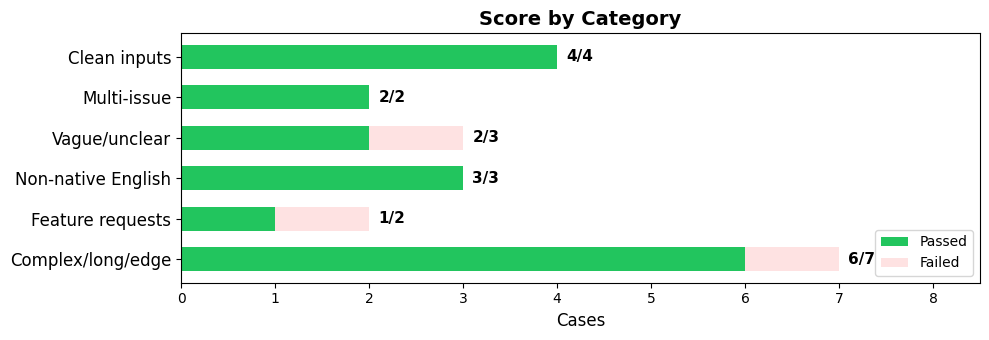

In [35]:
# ============================================================
# CHAIN MODE -- Use this if you split into multiple steps
# ============================================================

# Step 1: Classifier
step1_prompt = """
You are a support ticket priority classifier. Read the ticket and assign
exactly one priority (P1, P2, P3, or P4) based on business impact.

PRIORITY RUBRIC (evaluate in order; first match wins):

- P1 — Severe. ONLY if:
    a) Core workflow is FULLY blocked (cannot work at all, no workaround)
       AND revenue/payroll/compliance is at risk OR all users of an org
       cannot work, OR
    b) Security / privacy incident (PII exposure, auth bypass, data leak)
       — regardless of how many users reported it.
  NOT P1: degraded performance, broken feature with workaround, "urgent"
  language alone, "production system" alone, large user count alone.

- P2 — Major. A significant feature is broken, slow, or unreliable for
  many users, but work continues (workaround exists, retry succeeds, or
  other features function). Default for most real bugs in production.

- P3 — Minor. ANY of:
    • Bug affecting few users (≤ ~5) with no business-critical impact
    • Cosmetic / UI bug (truncated text, tooltip, layout, styling)
    • Intermittent issue with reliable workaround ("retry and it works")
    • Vague complaint with some signal of real degradation but no detail
    • Emotional / dissatisfied ticket with no specific feature ask

- P4 — Feature request ONLY. User is asking for new functionality that
  doesn't exist. Urgent tone, threats to churn, or the word "BUG" in
  the subject do NOT change this. Cosmetic bugs are P3, not P4.

CONFIDENCE:
- "high"   — explicit evidence in the ticket maps to one rubric branch.
- "medium" — criteria likely met, some inference from context.
- "low"    — vague or emotional ticket. Still assign a priority (usually
             P3). Only leave priority="" if there is literally no
             problem signal at all.

MULTI-ISSUE: If the ticket describes multiple distinct issues, classify
based on the HIGHEST-impact one.

Return ONLY this JSON, nothing else:
{"priority": "P1"|"P2"|"P3"|"P4", "confidence": "high"|"medium"|"low"}

"""

# Step 2: Entity Extractor
step2_prompt = """
You are an entity extractor for support tickets. Pull four fields from
the ticket text. Every value must be a VERBATIM substring of the ticket
or empty — no paraphrasing, normalization, or coining new terms.

FIELDS:
- product: the product/feature/module name as the user wrote it.
    • Use the exact phrase from the ticket (e.g., "inventory management
      module", "API integration", "Ñoño Analytics").
    • If the user only mentions a generic descriptor ("CRM tool",
      "the platform", "your system"), use that exact phrase or "".
    • Never invent a proper noun. "data sync issue" → "" (NOT "DataSync").
      "CRM tool" → "CRM tool" (NOT "CRM platform").

- version: a version number stated in the ticket (e.g., "3.2", "4.1.2",
  "5.0.1"). Empty string if none stated.

- error_codes: a list of error identifiers literally present in the
  ticket. Include:
    • Named codes ("SVC-503-AUTH", "VIZ-RENDER-408", "SYNC_FAILED")
    • HTTP status codes the user cites as errors ("500", "503", "429")
    • Quoted error messages ("timeout exceeded")
  Each entry must appear verbatim. Empty list if none.

- affected_users: a number stated in the ticket, as a string (e.g.,
  "200", "15", "1"). Words like "several", "a bunch", "many",
  "everyone", "the team" → "" (NEVER invent a number).

ANTI-HALLUCINATION RULES:
- If you cannot find a verbatim source in the ticket, the field is ""
  (or [] for error_codes). When in doubt, leave it empty.
- Do not normalize casing or punctuation. Copy the user's spelling.
- Do not infer entities from context ("they must mean product X").

Return ONLY this JSON:
{"product": "", "version": "", "error_codes": [], "affected_users": ""}
"""

# Step 3: Response Drafter
step3_prompt = """
You are drafting a customer-facing response for a support ticket. You
receive the original ticket plus the triage decisions already made
(priority + extracted entities). Use them; do not re-classify.

INPUTS YOU WILL RECEIVE:
- The original ticket text.
- priority: P1 | P2 | P3 | P4
- confidence: high | medium | low
- entities: {product, version, error_codes, affected_users}

RESPONSE RULES:
- Acknowledge EVERY issue raised in the ticket, not just the main one.
- Tone: professional and empathetic. Calm even if the user is angry or
  all-caps — never mirror their tone.
- Never promise a fix, root cause, or timeline that wasn't given to you.
- Reference only details that appear in the ticket or the entities
  above. Do not invent product names, versions, or error codes.
- Priority-specific framing:
    • P1: acknowledge severity, state it's being escalated immediately.
    • P2: acknowledge impact, confirm it's being investigated.
    • P3: thank them, confirm it's logged for the relevant team.
    • P4: thank them for the suggestion, confirm it's been logged as a
          feature request. Do NOT call it a bug or promise a fix, even
          if the user used the word "bug".
- If confidence is "low": ask 1-2 specific clarifying questions
  (which product / feature, exact error message, when it started,
  how many users affected). Keep it short.
- Plain text only, under 120 words. Paraphrase the user rather than
  quoting them verbatim (embedded quotes can break the JSON wrapper).
- No newlines inside the response. Use sentence breaks only.

OUTPUT — return ONLY this JSON, nothing before or after:
{
  "priority": "P1" | "P2" | "P3" | "P4",
  "entities": {
    "product": "",
    "version": "",
    "error_codes": [],
    "affected_users": ""
  },
  "response": "",
  "confidence": "high" | "medium" | "low"
}
All keys must be present. Use "" / [] for unknowns.

Return ONLY this JSON:
{"response": ""}
"""

# Run the chain (uncomment when ready)
results = run_eval_suite([step1_prompt, step2_prompt, step3_prompt], label="Chain v1")

In [ ]:
# ============================================================
# A/B COMPARISON -- Compare two prompt variants
# ============================================================

prompt_a = system_prompt  # Your current best

prompt_b = """
[Paste your variant here]
"""

# Run comparison (uncomment when ready)
# result_a, result_b = compare_prompts(prompt_a, prompt_b, label_a="Current Best", label_b="New Variant")

In [ ]:
# ============================================================
# ITERATION LOG -- Track your progress across runs
# ============================================================

# The eval harness automatically logs each run.
# Call this to see your iteration history and score progression:

show_iteration_log()

---

### Stuck? Ask Claude before you ask a facilitator.

Tell Claude exactly what you tried and what happened:

> "I'm iterating on a prompt. I tried [describe your change]. My score went from X to Y. The categories still failing are [list them]. What would you try next and why?"

You're not asking for the answer — you're running a diagnostic. Evaluate the suggestion against your own diagnosis before acting on it.

---

## Reflection — What Did *You* Do vs. What Did Claude Do?

This is where the real learning happens — and where strong partner engineers separate themselves.

Before you share your score, take 5 minutes to answer these questions honestly:

### 1. Where did your prompt engineering do the work?
Which improvements came from a deliberate structural decision you made — a chain step, an explicit constraint, a few-shot example, a null-handling instruction?

Write 2–3 specific examples: *"I added X because I diagnosed Y failure mode."*

### 2. Where did Claude's underlying capability do the work?
Some improvements will happen because Claude is already good at something — you just got out of its way. Be honest about the difference. *"Claude handled non-native English well once I stopped forcing it to fill all fields."*

### 3. What surprised you?
What didn't work the way you expected? What did Claude do better — or worse — than you predicted?

### 4. What would you tell a CTO?
If you had 90 seconds to explain your architecture to a technical decision-maker, what would you say? Draft it here before sharing.

---

## Get a Personal Analysis from Claude

Once you've reflected, paste your final score and answers into a new Claude conversation using this prompt:

```
I just completed a prompt engineering exercise. Here's my summary:

Final score: [X/21 — Y%]
Baseline: [X/21 — Y%]

Techniques I used:
[List them + brief rationale for each]

Where my engineering did the work:
[Your answer from question 1]

Where Claude's capability did the work:
[Your answer from question 2]

What surprised me:
[Your answer from question 3]

Please give me a candid analysis:
1. Where did my prompt engineering approach shine?
2. Where did I rely on Claude's capability when I should have engineered more explicitly?
3. What would make my approach more defensible in an enterprise context?
4. What's one technique I didn't use that would likely push my score higher?
```

---

## Stretch: Process Audit

*For fast finishers who've hit a strong score. Optional.*

This is the question that separates a methodology from a demo: **did you do the work, or did Claude?**

### Step 1: Ask Claude to audit your process

Open a new Claude conversation and send this:

```
Here's my original prompt:
[paste the broken prompt from Cell 3]

Here's my final prompt (or chain):
[paste your best version]

Score progression: [paste from your iteration log]

How much of this improvement came from diagnostic decisions I made — and how much would have happened if you'd just rewritten the prompt from scratch without the eval loop?
```

### Step 2: Run the experiment

Ask Claude to fix the original prompt directly — no methodology, just: *"Here's a broken support ticket classifier. Rewrite it to fix the failures. Return only the improved prompt."*

Paste Claude's rewrite into the cell below and run it.

### Step 3: Compare

Same score? Different score? Either way, the real question is: can you explain *why* your approach works in a way you could repeat on a different broken prompt next week?

A score you can explain is a methodology. A score you can't is a demo.

---

In [ ]:
# ============================================================
# PROCESS AUDIT -- Compare your approach vs. Claude's direct fix
# ============================================================

claude_fix = """
[Paste Claude's direct rewrite here]
"""

results_audit = run_eval_suite(claude_fix, label="Claude direct fix")

## How to Present This to an Enterprise Buyer

The goal of this exercise isn't just a better score — it's building the confidence to walk a technical buyer through a real prompt engineering engagement. Here's how.

### The Narrative Arc

| Beat | What to Say | Why It Works |
|------|-------------|--------------|
| **The problem** | "Your prompt does too many things at once, and the tasks interfere with each other." | Diagnoses the root cause, not the symptom. |
| **The diagnosis** | "I used Claude to analyze its own failure modes — here's what it identified." | Shows meta-prompting in action. Buyers respond to this. |
| **The fix** | "I decomposed it into a [N]-step chain: classify first, extract second, respond third. Each step is focused and can't pollute the others." | Demonstrates architectural thinking, not just prompt tweaking. |
| **The proof** | "Before: 19% pass rate. After: 86%. Here's the category breakdown — feature requests improved most because we're now evaluating content, not tone." | Quantitative. Specific. Defensible. |
| **The prevention** | "Here's a 3-question checklist your team can run on every new prompt before shipping to production." | Leaves them with something they can use. |

### What Separates Good from Great

- **Good:** "I fixed the prompt and the score went up."
- **Great:** "I diagnosed the structural failure mode, chose a technique that specifically addresses it, and can show you the delta across each failure category."

The second version is what closes enterprise deals.

### One Thing to Never Say

Never say "I just asked Claude to fix it." Even if meta-prompting helped, own the diagnostic judgment. You decided what to ask. You evaluated the result. You made the call on which fix to ship. That's the value you bring.